# **LinkedIn Freelancer Survey Results**

## **Import**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv('/content/results.csv')
display(df.head())

,question,A,B,C,D,respondents
0,1,0.66,0.17,0.17,0.00,6
1,2,0.25,0.67,0.08,0.00,12
2,3,0.23,0.38,0.16,0.23,13
3,4,0.47,0.20,0.33,0.00,15
4,5,0.53,0.12,0.12,0.23,17


In [ ]:
df.tail()

,question,A,B,C,D,respondents
45,46,0.23,0.55,0.08,0.14,146
46,47,0.03,0.56,0.41,0.00,147
47,48,0.20,0.37,0.36,0.07,148
48,49,0.08,0.43,0.41,0.08,302
49,50,0.42,0.40,0.10,0.08,478


In [ ]:
# Dataset shape
print("Dataset Shape:")
display(df.shape)

# Column names
print("\nColumn Names:")
display(df.columns.tolist())

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

# Data types
print("\nData Types:")
display(df.dtypes)

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Unique values
print("\nUnique Values:")
display(df.nunique())

Dataset Shape:


(50, 6)


Column Names:


['question', 'A', 'B', 'C', 'D', 'respondents']


First 5 Rows:


...

,0
question,int64
A,float64
B,float64
C,float64
D,float64
respondents,int64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   question     50 non-null     int64  
 1   A            50 non-null     float64
 2   B            50 non-null     float64
 3   C            50 non-null     float64
 4   D            50 non-null     float64
 5   respondents  50 non-null     int64  
dtypes: float64(4), int64(2)
memory usage: 2.5 KB

Missing Values:


,0
question,0
A,0
B,0
C,0
D,0
respondents,0



Unique Values:


,0
question,50
A,33
B,36
C,34
D,26
respondents,44


**Data Cleaning**

In [ ]:
# Create a copy of the original dataset
clean_df = df.copy()

# Check duplicate rows
duplicate_count = clean_df.duplicated().sum()

# Check missing values
missing_values = clean_df.isnull().sum()

# Check negative values in numeric columns
numeric_columns = clean_df.select_dtypes(include="number").columns
negative_values = (clean_df[numeric_columns] < 0).sum()

# Check data types
data_types = clean_df.dtypes

# Cleaning Summary
print("DATA CLEANING SUMMARY")

print("Original Dataset Shape:")
display(df.shape)

print("Duplicate Rows:")
display(duplicate_count)

print("Missing Values:")
display(missing_values)

print("Negative Values:")
display(negative_values)

print("Data Types:")
display(data_types)

# Remove duplicate rows
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Final shape
display("Final Cleaned Dataset Shape:")
display(clean_df.shape)

DATA CLEANING SUMMARY
Original Dataset Shape:


(50, 6)

Duplicate Rows:


np.int64(0)

Missing Values:


...

,0
question,0
A,0
B,0
C,0
D,0
respondents,0


Data Types:


,0
question,int64
A,float64
B,float64
C,float64
D,float64
respondents,int64


'Final Cleaned Dataset Shape:'

(50, 6)

## **Exploratory Data Analysis (EDA)**

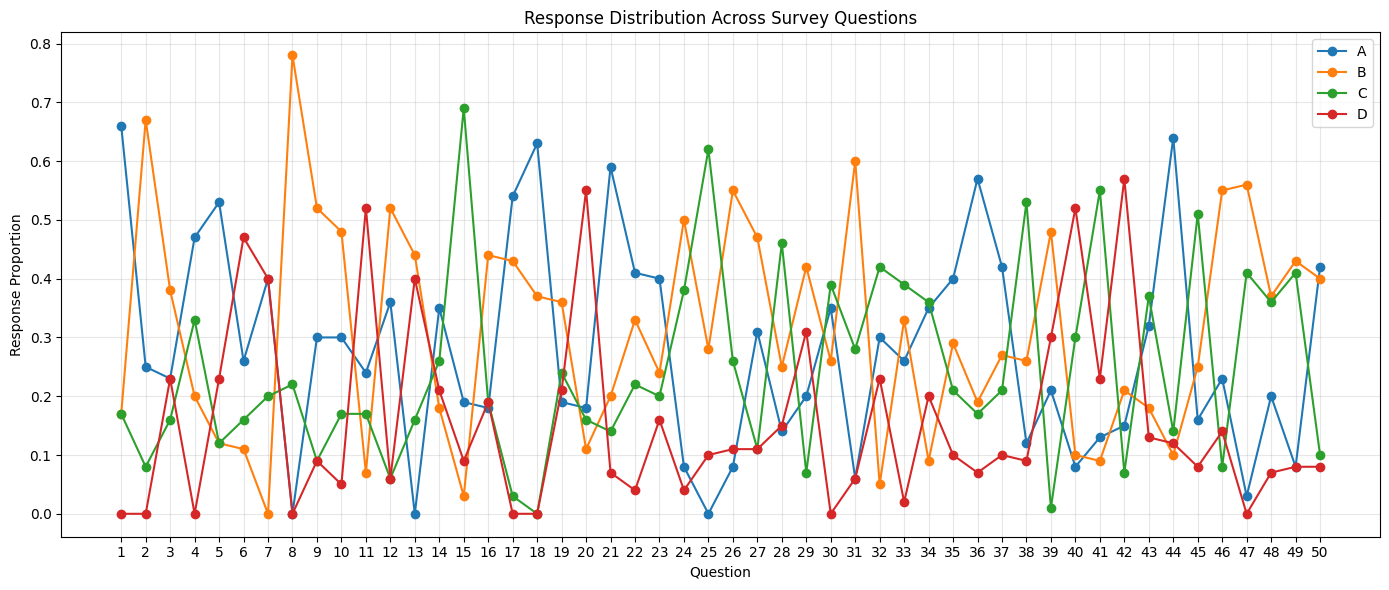

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["question"], df["A"], marker="o", label="A")
plt.plot(df["question"], df["B"], marker="o", label="B")
plt.plot(df["question"], df["C"], marker="o", label="C")
plt.plot(df["question"], df["D"], marker="o", label="D")

plt.title("Response Distribution Across Survey Questions")
plt.xlabel("Question")
plt.ylabel("Response Proportion")
plt.xticks(df["question"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["question"],
    y=df["A"],
    mode="lines+markers",
    name="A"
))

fig.add_trace(go.Scatter(
    x=df["question"],
    y=df["B"],
    mode="lines+markers",
    name="B"
))

fig.add_trace(go.Scatter(
    x=df["question"],
    y=df["C"],
    mode="lines+markers",
    name="C"
))

fig.add_trace(go.Scatter(
    x=df["question"],
    y=df["D"],
    mode="lines+markers",
    name="D"
))

fig.update_layout(
    title="Interactive Response Distribution Across Questions",
    xaxis_title="Question",
    yaxis_title="Response Proportion",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

In [ ]:
fig = px.bar(
    df,
    x="question",
    y="respondents",
    title="Number of Respondents per Survey Question",
    labels={
        "question": "Question",
        "respondents": "Number of Respondents"
    },
    template="plotly_white",
    text="respondents"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df["question"],
    y=df["A"],
    name="A"
))

fig.add_trace(go.Bar(
    x=df["question"],
    y=df["B"],
    name="B"
))

fig.add_trace(go.Bar(
    x=df["question"],
    y=df["C"],
    name="C"
))

fig.add_trace(go.Bar(
    x=df["question"],
    y=df["D"],
    name="D"
))

fig.update_layout(
    barmode="stack",
    title="Response Composition by Survey Question",
    xaxis_title="Question",
    yaxis_title="Response Proportion",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

**Response Proportion Analysis**

In [ ]:
response_columns = ["A", "B", "C", "D"]

average_response = df[response_columns].mean().reset_index()
average_response.columns = ["Response", "Average_Proportion"]

print("Average Response Proportion:")
display(average_response)

Average Response Proportion:


,Response,Average_Proportion
0,A,0.2790
1,B,0.3136
2,C,0.2478
3,D,0.1596


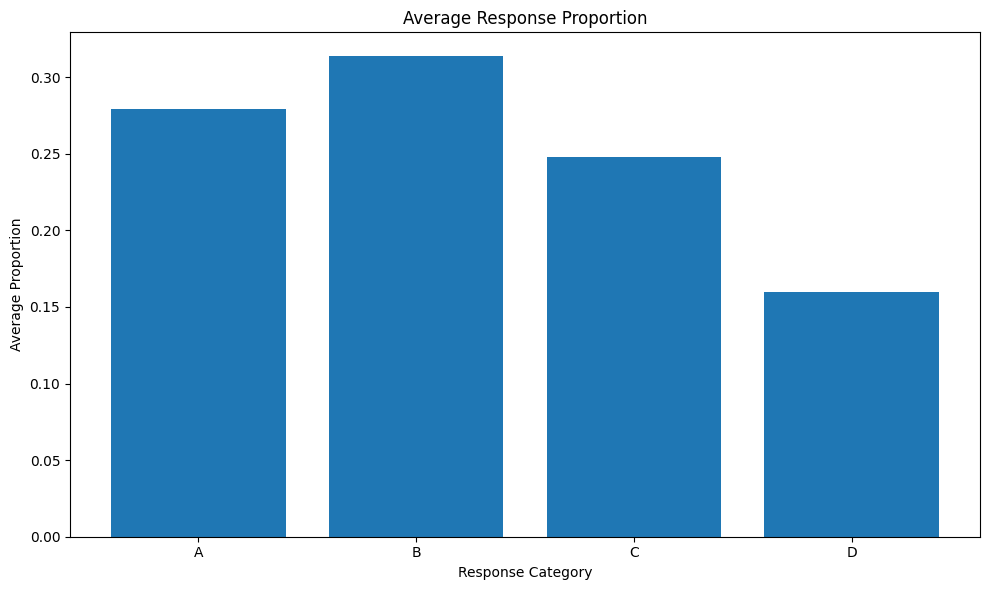

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    average_response["Response"],
    average_response["Average_Proportion"]
)

plt.title("Average Response Proportion")
plt.xlabel("Response Category")
plt.ylabel("Average Proportion")

plt.tight_layout()
plt.show()

In [ ]:
fig = px.bar(
    average_response,
    x="Response",
    y="Average_Proportion",
    title="Average Response Proportion by Category",
    text="Average_Proportion",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Response Category",
    yaxis_title="Average Proportion"
)

fig.show()

In [ ]:
fig = px.box(
    df,
    y=["A", "B", "C", "D"],
    title="Distribution of Response Proportions",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Response Category",
    yaxis_title="Response Proportion"
)

fig.show()

In [ ]:
correlation = df[["A", "B", "C", "D", "respondents"]].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,A,B,C,D,respondents
A,1.000000,-0.350804,-0.444969,-0.254586,-0.074781
B,-0.350804,1.000000,-0.302349,-0.453294,0.079025
C,-0.444969,-0.302349,1.000000,-0.183650,0.094751
D,-0.254586,-0.453294,-0.183650,1.000000,-0.105592
respondents,-0.074781,0.079025,0.094751,-0.105592,1.000000


In [ ]:
fig = px.imshow(
    correlation,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap of Survey Variables",
    color_continuous_scale="RdBu_r"
)

fig.show()

## **Feature Engineering**

In [ ]:
model_df = clean_df.copy()

response_columns = ["A", "B", "C", "D"]

# Average response proportion
model_df["Average_Response"] = model_df[response_columns].mean(axis=1)

# Maximum response proportion
model_df["Max_Response"] = model_df[response_columns].max(axis=1)

# Minimum response proportion
model_df["Min_Response"] = model_df[response_columns].min(axis=1)

# Response range
model_df["Response_Range"] = (
    model_df["Max_Response"] -
    model_df["Min_Response"]
)

# Standard deviation of responses
model_df["Response_Std"] = model_df[response_columns].std(axis=1)

print("Feature Engineered Dataset:")
display(model_df.head())

Feature Engineered Dataset:


,question,A,B,C,D,respondents,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std
0,1,0.66,0.17,0.17,0.00,6,0.25,0.66,0.00,0.66,0.284839
1,2,0.25,0.67,0.08,0.00,12,0.25,0.67,0.00,0.67,0.298775
2,3,0.23,0.38,0.16,0.23,13,0.25,0.38,0.16,0.22,0.092736
3,4,0.47,0.20,0.33,0.00,15,0.25,0.47,0.00,0.47,0.199833
4,5,0.53,0.12,0.12,0.23,17,0.25,0.53,0.12,0.41,0.193735


In [ ]:
print("FEATURE ENGINEERING SUMMARY")

print("Original Features:")
display(clean_df.columns.tolist())

print("New Features:")
display([
    "Average_Response",
    "Max_Response",
    "Min_Response",
    "Response_Range",
    "Response_Std"
])

print("Final Dataset Shape:")
display(model_df.shape)

FEATURE ENGINEERING SUMMARY
Original Features:


['question', 'A', 'B', 'C', 'D', 'respondents']

New Features:


['Average_Response',
 'Max_Response',
 'Min_Response',
 'Response_Range',
 'Response_Std']

Final Dataset Shape:


(50, 11)

In [ ]:
feature_columns = [
    "Average_Response",
    "Max_Response",
    "Min_Response",
    "Response_Range",
    "Response_Std"
]

feature_long = model_df[feature_columns].melt(
    var_name="Feature",
    value_name="Value"
)

fig = px.box(
    feature_long,
    x="Feature",
    y="Value",
    title="Distribution of Engineered Features",
    template="plotly_white"
)

fig.show()

In [ ]:
feature_corr = model_df[
    ["A", "B", "C", "D", "respondents",
     "Average_Response",
     "Max_Response",
     "Min_Response",
     "Response_Range",
     "Response_Std"]
].corr()

fig = px.imshow(
    feature_corr,
    text_auto=".2f",
    aspect="auto",
    title="Feature Correlation Matrix",
    color_continuous_scale="RdBu_r"
)

fig.show()

## **ML Preparation: Select Features & Target**

In [ ]:
# Target variable
target = "respondents"

# Feature variables
features = [
    "A",
    "B",
    "C",
    "D",
    "Average_Response",
    "Max_Response",
    "Min_Response",
    "Response_Range",
    "Response_Std"
]

# Create X and y
X = model_df[features]
y = model_df[target]

print("ML DATA PREPARATION")

print("Feature Columns:")
display(features)

print("Target Column:")
display(target)

print("X Shape:")
display(X.shape)

print("y Shape:")
display(y.shape)

print("X:")
display(X.head())

print("y:")
display(y.head())

ML DATA PREPARATION
Feature Columns:


['A',
 'B',
 'C',
 'D',
 'Average_Response',
 'Max_Response',
 'Min_Response',
 'Response_Range',
 'Response_Std']

Target Column:


'respondents'

X Shape:


...

(50,)

X:


,A,B,C,D,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std
0,0.66,0.17,0.17,0.00,0.25,0.66,0.00,0.66,0.284839
1,0.25,0.67,0.08,0.00,0.25,0.67,0.00,0.67,0.298775
2,0.23,0.38,0.16,0.23,0.25,0.38,0.16,0.22,0.092736
3,0.47,0.20,0.33,0.00,0.25,0.47,0.00,0.47,0.199833
4,0.53,0.12,0.12,0.23,0.25,0.53,0.12,0.41,0.193735


y:


,respondents
0,6
1,12
2,13
3,15
4,17


In [ ]:
print("Missing Values in X:")
display(X.isnull().sum())

print("Missing Values in y:")
display(y.isnull().sum())

Missing Values in X:


,0
A,0
B,0
C,0
D,0
Average_Response,0
Max_Response,0
Min_Response,0
Response_Range,0
Response_Std,0


Missing Values in y:


np.int64(0)

In [ ]:
display("Feature Statistics:")
display(X.describe())

'Feature Statistics:'

,A,B,C,D,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std
count,50.00000,50.000000,50.000000,50.000000,5.000000e+01,50.000000,50.000000,50.000000,50.000000
mean,0.27900,0.313600,0.247800,0.159600,2.500000e-01,0.497400,0.070200,0.427200,0.196323
std,0.17695,0.182966,0.163061,0.157933,7.930164e-18,0.099094,0.053433,0.131786,0.062345
min,0.00000,0.000000,0.000000,0.000000,2.500000e-01,0.350000,0.000000,0.170000,0.074386
25%,0.15250,0.180000,0.140000,0.060000,2.500000e-01,0.420000,0.022500,0.350000,0.155871
50%,0.25500,0.285000,0.205000,0.100000,2.500000e-01,0.490000,0.070000,0.435000,0.195959
75%,0.40000,0.440000,0.367500,0.225000,2.500000e-01,0.550000,0.100000,0.492500,0.224268
max,0.66000,0.780000,0.690000,0.570000,2.500000e-01,0.780000,0.190000,0.780000,0.368239


In [ ]:
fig = px.histogram(
    model_df,
    x="respondents",
    nbins=10,
    title="Distribution of Number of Respondents",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Number of Respondents",
    yaxis_title="Frequency"
)

fig.show()

In [ ]:
fig = px.scatter_matrix(
    model_df,
    dimensions=features,
    color="respondents",
    title="Feature Relationships and Respondent Distribution",
    template="plotly_white"
)

fig.update_traces(
    diagonal_visible=False,
    showupperhalf=False
)

fig.show()

## **Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("TRAIN / TEST SPLIT")

print("Total Samples:")
display(len(X))

print("Training Samples:")
display(len(X_train))

print("Testing Samples:")
display(len(X_test))

print("Training Percentage:")
display(round(len(X_train) / len(X) * 100, 2), "%")

print("Testing Percentage:")
display(round(len(X_test) / len(X) * 100, 2), "%")

print("X_train Shape:")
display(X_train.shape)

print("X_test Shape:")
display(X_test.shape)

print("y_train Shape:")
display(y_train.shape)

print("y_test Shape:")
display(y_test.shape)

TRAIN / TEST SPLIT
Total Samples:


50

Training Samples:


40

Testing Samples:


...

(10, 9)

y_train Shape:


(40,)

y_test Shape:


(10,)

In [ ]:
print("Training Features:")
display(X_train.head())

print("Training Target:")
display(y_train.head())

Training Features:


,A,B,C,D,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std
12,0.00,0.44,0.16,0.40,0.25,0.44,0.00,0.44,0.207525
4,0.53,0.12,0.12,0.23,0.25,0.53,0.12,0.41,0.193735
37,0.12,0.26,0.53,0.09,0.25,0.53,0.09,0.44,0.200832
8,0.30,0.52,0.09,0.09,0.25,0.52,0.09,0.43,0.205426
3,0.47,0.20,0.33,0.00,0.25,0.47,0.00,0.47,0.199833


Training Target:


,respondents
12,32
4,17
37,74
8,23
3,15


In [ ]:
print("Testing Features:")
display(X_test.head())

print("Testing Target:")
display(y_test.head())

Testing Features:


,A,B,C,D,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std
13,0.35,0.18,0.26,0.21,0.25,0.35,0.18,0.17,0.074386
39,0.08,0.10,0.30,0.52,0.25,0.52,0.08,0.44,0.205589
30,0.06,0.60,0.28,0.06,0.25,0.60,0.06,0.54,0.255343
45,0.23,0.55,0.08,0.14,0.25,0.55,0.08,0.47,0.209284
17,0.63,0.37,0.00,0.00,0.25,0.63,0.00,0.63,0.307571


Testing Target:


,respondents
13,34
39,86
30,63
45,146
17,41


## **Model Training**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Initialize models
linear_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train Linear Regression
linear_model.fit(X_train, y_train)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Train Gradient Boosting
gb_model.fit(X_train, y_train)



print("Linear Regression:")
print("Training completed successfully")

print("Random Forest Regression:")
print("Training completed successfully")

print("Gradient Boosting Regression:")
print("Training completed successfully")

Linear Regression:
Training completed successfully
Random Forest Regression:
Training completed successfully
Gradient Boosting Regression:
Training completed successfully


In [ ]:
print("Linear Regression Parameters:")
display(linear_model.get_params())

print("Random Forest Parameters:")
display(rf_model.get_params())

print("Gradient Boosting Parameters:")
display(gb_model.get_params())

Linear Regression Parameters:


{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

Random Forest Parameters:


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Gradient Boosting Parameters:


{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.05,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 200,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
linear_train_score = linear_model.score(X_train, y_train)
rf_train_score = rf_model.score(X_train, y_train)
gb_train_score = gb_model.score(X_train, y_train)

print("Training R² Scores:")

print(
    "Linear Regression:",
    round(linear_train_score, 4)
)

print(
    "Random Forest:",
    round(rf_train_score, 4)
)

print(
    "Gradient Boosting:",
    round(gb_train_score, 4)
)

Training R² Scores:
Linear Regression: 0.2147
Random Forest: 0.8188
Gradient Boosting: 0.9996


## **Model Evaluation**

In [ ]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions
linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Evaluation function
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

# Evaluate models
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

# Results DataFrame
evaluation_df = pd.DataFrame(results)

print("MODEL EVALUATION")

display(evaluation_df.round(4))

MODEL EVALUATION


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,41.7829,3559.9744,59.6655,0.4031
1,Random Forest,40.6060,4035.6381,63.5267,0.3233
2,Gradient Boosting,36.7932,3637.6893,60.3133,0.3900


In [ ]:
best_model_name = evaluation_df.loc[
    evaluation_df["RMSE"].idxmin(),
    "Model"
]

display("Best Model Based on RMSE:")
display(best_model_name)

'Best Model Based on RMSE:'

'Linear Regression'

In [ ]:
fig = px.bar(
    evaluation_df,
    x="Model",
    y="RMSE",
    title="Model Comparison — RMSE",
    text="RMSE",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="RMSE"
)

fig.show()

In [ ]:
fig = px.bar(
    evaluation_df,
    x="Model",
    y="R²",
    title="Model Comparison — R² Score",
    text="R²",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="R² Score"
)

fig.show()

In [ ]:
# Select predictions for the best model
if best_model_name == "Linear Regression":
    best_predictions = linear_pred

elif best_model_name == "Random Forest":
    best_predictions = rf_pred

else:
    best_predictions = gb_pred

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

fig = px.scatter(
    prediction_df,
    x="Actual",
    y="Predicted",
    title=f"Actual vs Predicted — {best_model_name}",
    template="plotly_white",
    trendline="ols"
)

fig.update_layout(
    xaxis_title="Actual Respondents",
    yaxis_title="Predicted Respondents"
)

fig.show()

## **Prediction**

In [ ]:
# Generate predictions using the best model
if best_model_name == "Linear Regression":
    final_model = linear_model

elif best_model_name == "Random Forest":
    final_model = rf_model

else:
    final_model = gb_model

# Predictions
final_predictions = final_model.predict(X_test)


print("MODEL PREDICTIONS")

display("Selected Model:")
print(best_model_name)

display("Predictions:")
print(final_predictions)

MODEL PREDICTIONS


'Selected Model:'

Linear Regression


'Predictions:'

[ 83.75685427  70.67525535  69.60332616  33.16651995  98.86792184
 178.1245712   91.18222701  53.72953751  72.04997925  52.60504955]


In [ ]:
prediction_results = X_test.copy()

prediction_results["Actual_Respondents"] = y_test.values
prediction_results["Predicted_Respondents"] = final_predictions

prediction_results["Prediction_Error"] = (
    prediction_results["Actual_Respondents"]
    - prediction_results["Predicted_Respondents"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Prediction_Error"].abs()
)

print("Actual vs Predicted Results:")
display(prediction_results.round(2))

Actual vs Predicted Results:


,A,B,C,D,Average_Response,Max_Response,Min_Response,Response_Range,Response_Std,Actual_Respondents,Predicted_Respondents,Prediction_Error,Absolute_Error
13,0.35,0.18,0.26,0.21,0.25,0.35,0.18,0.17,0.07,34,83.76,-49.76,49.76
39,0.08,0.10,0.30,0.52,0.25,0.52,0.08,0.44,0.21,86,70.68,15.32,15.32
30,0.06,0.60,0.28,0.06,0.25,0.60,0.06,0.54,0.26,63,69.60,-6.60,6.60
45,0.23,0.55,0.08,0.14,0.25,0.55,0.08,0.47,0.21,146,33.17,112.83,112.83
17,0.63,0.37,0.00,0.00,0.25,0.63,0.00,0.63,0.31,41,98.87,-57.87,57.87
48,0.08,0.43,0.41,0.08,0.25,0.43,0.08,0.35,0.20,302,178.12,123.88,123.88
26,0.31,0.47,0.11,0.11,0.25,0.47,0.11,0.36,0.17,55,91.18,-36.18,36.18
25,0.08,0.55,0.26,0.11,0.25,0.55,0.08,0.47,0.21,53,53.73,-0.73,0.73
32,0.26,0.33,0.39,0.02,0.25,0.39,0.02,0.37,0.16,66,72.05,-6.05,6.05
19,0.18,0.11,0.16,0.55,0.25,0.55,0.11,0.44,0.20,44,52.61,-8.61,8.61


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(1, len(y_test) + 1)),
    y=y_test.values,
    mode="lines+markers",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=list(range(1, len(y_test) + 1)),
    y=final_predictions,
    mode="lines+markers",
    name="Predicted"
))

fig.update_layout(
    title=f"Actual vs Predicted Respondents — {best_model_name}",
    xaxis_title="Test Sample",
    yaxis_title="Number of Respondents",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

In [ ]:
fig = px.bar(
    prediction_results.reset_index(),
    x="index",
    y="Prediction_Error",
    title="Prediction Error for Test Samples",
    labels={
        "index": "Test Sample",
        "Prediction_Error": "Prediction Error"
    },
    template="plotly_white"
)

fig.add_hline(
    y=0,
    line_dash="dash"
)

fig.show()

In [ ]:
mae = mean_absolute_error(
    y_test,
    final_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

r2 = r2_score(
    y_test,
    final_predictions
)



display("Best Model:")
display(best_model_name)

display("MAE:")
display(round(mae, 4))

display("RMSE:")
display(round(rmse, 4))

display("R² Score:")
display(round(r2, 4))

'Best Model:'

'Linear Regression'

'MAE:'

41.7829

'RMSE:'

np.float64(59.6655)

'R² Score:'

0.4031

## **Feature Importance**

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display("FEATURE IMPORTANCE")

display(feature_importance.round(4))

'FEATURE IMPORTANCE'

,Feature,Importance
2,C,0.2744
7,Response_Range,0.1641
1,B,0.1292
0,A,0.1238
8,Response_Std,0.0940
3,D,0.0915
5,Max_Response,0.0663
6,Min_Response,0.0567
4,Average_Response,0.0000


In [ ]:
fig = px.bar(
    feature_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Random Forest Feature Importance",
    text="Importance",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    },
    xaxis_title="Importance",
    yaxis_title="Feature"
)

fig.show()

In [ ]:
top_feature = feature_importance.iloc[0]

display("Most Important Feature:")
display(top_feature["Feature"])

display("Importance:")
display(round(top_feature["Importance"], 4))

'Most Important Feature:'

'C'

'Importance:'

np.float64(0.2744)

In [ ]:
feature_importance["Importance_Percentage"] = (
    feature_importance["Importance"] * 100
)

display(
    feature_importance[
        ["Feature", "Importance_Percentage"]
    ].round(2)
)

,Feature,Importance_Percentage
2,C,27.44
7,Response_Range,16.41
1,B,12.92
0,A,12.38
8,Response_Std,9.40
3,D,9.15
5,Max_Response,6.63
6,Min_Response,5.67
4,Average_Response,0.00


## **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4]
}

rf_base = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

tuned_rf_model = grid_search.best_estimator_

In [ ]:
display("BEST RANDOM FOREST PARAMETERS")

print(grid_search.best_params_)

print("Best Cross-Validation RMSE:")
print(round(-grid_search.best_score_, 4))

'BEST RANDOM FOREST PARAMETERS'

{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation RMSE:
68.9869


In [ ]:
# Predictions from tuned model
tuned_rf_pred = tuned_rf_model.predict(X_test)

# Metrics
tuned_mae = mean_absolute_error(
    y_test,
    tuned_rf_pred
)

tuned_mse = mean_squared_error(
    y_test,
    tuned_rf_pred
)

tuned_rmse = np.sqrt(tuned_mse)

tuned_r2 = r2_score(
    y_test,
    tuned_rf_pred
)

tuned_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Tuned Random Forest": [
        tuned_mae,
        tuned_mse,
        tuned_rmse,
        tuned_r2
    ]
})

print("Tuned Random Forest Evaluation:")
display(tuned_results.round(4))

Tuned Random Forest Evaluation:


,Metric,Tuned Random Forest
0,MAE,39.0184
1,MSE,4632.8064
2,RMSE,68.0647
3,R²,0.2232


In [ ]:
original_rf_pred = rf_model.predict(X_test)

original_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        original_rf_pred
    )
)

original_rf_r2 = r2_score(
    y_test,
    original_rf_pred
)

comparison_df = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "RMSE": [
        original_rf_rmse,
        tuned_rmse
    ],
    "R²": [
        original_rf_r2,
        tuned_r2
    ]
})

display("Original vs Tuned Random Forest:")
display(comparison_df.round(4))

'Original vs Tuned Random Forest:'

,Model,RMSE,R²
0,Original Random Forest,63.5267,0.3233
1,Tuned Random Forest,68.0647,0.2232


In [ ]:
fig = px.bar(
    comparison_df,
    x="Model",
    y="RMSE",
    title="Original vs Tuned Random Forest — RMSE",
    text="RMSE",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="RMSE"
)

fig.show()

In [ ]:
if tuned_rmse < original_rf_rmse:
    final_model = tuned_rf_model
    final_model_name = "Tuned Random Forest"
else:
    final_model = rf_model
    final_model_name = "Random Forest"

final_predictions = final_model.predict(X_test)



display("Selected Model:")
display(final_model_name)

display("Final RMSE:")
display(
    round(
        np.sqrt(
            mean_squared_error(
                y_test,
                final_predictions
            )
        ),
        4
    )
)

display("Final R²:")
display(
    round(
        r2_score(
            y_test,
            final_predictions
        ),
        4
    )
)

'Selected Model:'

'Random Forest'

'Final RMSE:'

np.float64(63.5267)

'Final R²:'

0.3233

## **Final Model Visualization**

In [ ]:
final_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions
})

fig = px.scatter(
    final_prediction_df,
    x="Actual",
    y="Predicted",
    title=f"Actual vs Predicted Respondents — {final_model_name}",
    template="plotly_white",
    trendline="ols"
)

# Perfect prediction reference line
min_value = min(
    final_prediction_df["Actual"].min(),
    final_prediction_df["Predicted"].min()
)

max_value = max(
    final_prediction_df["Actual"].max(),
    final_prediction_df["Predicted"].max()
)

fig.add_shape(
    type="line",
    x0=min_value,
    y0=min_value,
    x1=max_value,
    y1=max_value,
    line=dict(dash="dash")
)

fig.update_layout(
    xaxis_title="Actual Respondents",
    yaxis_title="Predicted Respondents"
)

fig.show()

In [ ]:
comparison_predictions = pd.DataFrame({
    "Sample": range(1, len(y_test) + 1),
    "Actual": y_test.values,
    "Predicted": final_predictions
})

fig = go.Figure()

fig.add_trace(go.Bar(
    x=comparison_predictions["Sample"],
    y=comparison_predictions["Actual"],
    name="Actual"
))

fig.add_trace(go.Bar(
    x=comparison_predictions["Sample"],
    y=comparison_predictions["Predicted"],
    name="Predicted"
))

fig.update_layout(
    barmode="group",
    title=f"Actual vs Predicted Respondents — {final_model_name}",
    xaxis_title="Test Sample",
    yaxis_title="Respondents",
    template="plotly_white"
)

fig.show()

In [ ]:
final_error = y_test.values - final_predictions

error_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Error": final_error,
    "Absolute_Error": np.abs(final_error)
})

print("FINAL ERROR ANALYSIS")

display(error_df.round(2))

FINAL ERROR ANALYSIS


,Actual,Predicted,Error,Absolute_Error
0,34,52.52,-18.52,18.52
1,86,63.56,22.44,22.44
2,63,57.15,5.85,5.85
3,146,63.50,82.50,82.50
4,41,93.44,-52.44,52.44
5,302,131.84,170.16,170.16
6,55,80.30,-25.30,25.30
7,53,62.12,-9.12,9.12
8,66,80.71,-14.71,14.71
9,44,49.02,-5.02,5.02


In [ ]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_predictions
)

final_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Score": [
        final_mae,
        final_mse,
        final_rmse,
        final_r2
    ]
})

print("FINAL MODEL PERFORMANCE")

display(final_metrics.round(4))

FINAL MODEL PERFORMANCE


,Metric,Score
0,MAE,40.6060
1,MSE,4035.6381
2,RMSE,63.5267
3,R²,0.3233


In [ ]:
dashboard_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Score": [
        final_mae,
        final_mse,
        final_rmse,
        final_r2
    ]
})

fig = px.bar(
    dashboard_df,
    x="Metric",
    y="Score",
    text="Score",
    title=f"Final Model Performance — {final_model_name}",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Evaluation Metric",
    yaxis_title="Score"
)

fig.show()

## **Project Report**

### **LINKEDIN FREELANCER SURVEY MACHINE LEARNING**

>**PROJECT OBJECTIVE**
------------------
Predict the number of respondents based on
LinkedIn Freelancer Survey response proportions.


**MACHINE LEARNING APPROACH**
-------------------------
1. Data Overview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. ML Preparation
6. Train/Test Split
7. Model Training
8. Model Evaluation
9. Prediction
10. Feature Importance
11. Hyperparameter Tuning
12. Final Model Visualization
13. Final Project Report

**FEATURES**
--------
A
B
C
D
Average_Response
Max_Response
Min_Response
Response_Range
Response_Std

**TARGET**
------
respondents

**DATA SPLIT**
----------
Training Data: 80%
Testing Data : 20%

**MODELS TRAINED**
---------------
Linear Regression
Random Forest Regression
Gradient Boosting Regression

**MODEL EVALUATION**
----------------
Evaluation Metrics:
- MAE
- MSE
- RMSE
- R² Score

**HYPERPARAMETER TUNING**
---------------------
Random Forest Regression was optimized
using GridSearchCV with 5-fold cross-validation.

**FINAL MODEL**
-----------
Random Forest
- Final MAE: 40.606
- Final MSE: 4035.6381
- Final RMSE: 63.5267
- Final R² Score: 0.3233

>**CONCLUSION**
----------
The final machine learning model was trained to predict
the number of respondents using LinkedIn Freelancer Survey
response characteristics.

The model was evaluated using multiple regression metrics
and the final model was selected after model comparison
and Random Forest hyperparameter tuning.

### **END**